# Evaluation of Audio Models

## 1 Overview

In this notebook we compare six pretrained speech emotion recognition models on the RAVDESS dataset [1]. The actor independent validation and testing manifests created during the dataset preparation are used to ensure speakers do not appear in both splits. The evaluation only considers six common emotions which are anger, disgust, fear, happiness, neutral and sadness. Calm and surprise recordings are excluded from the six-class evaluation.

Using macro-F1 as the primary metric, the models are compared and the best candidate is chosen using the validation split. Accuracy, macro-precision, macro-recall, model-loading time and inference time are also highlighted. Only the selected model is evaluated on the held-out test split. This notebook does not train or fine-tune any models.

## 2 Importing Libraries

This section imports the whole toolchain for speech-emotion evaluation. The set is wider than the text notebook as audio includes signal loading and several model families. Each recording is loaded from disk and resampled to the rate that each model expects, which is important as the RAVDESS files and the candidate models do not all assume the same sampling rate. The models are executed through various interfaces depending on their architectures the Hugging Face pipeline for the AST, HuBERT and DistilHuBERT candidates, and dedicated Transformers classes for the custom Wav2Vec2 classification head and for MERaLiON-SER which requires trusting remote code. 

Again, scikit-learn is used to provide the multiclass metrics accuracy and macro precision/recall/F1 and the ROC and precision-recall utilities, so the audio results are methodologically comparable with the other modalities. NumPy and pandas for the arrays and results tables matplotlib for the comparison chart and confusion matrix torch and torch.nn for the tensor backend, the custom model definition and GPU access. The gc module is used for garbage collection, re normalises label strings, and time measures loading and processing time.

In [1]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
# import required libraries
from pathlib import Path
import gc
import re
import time
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoConfig, AutoFeatureExtractor, AutoProcessor, AutoModelForAudioClassification, Wav2Vec2Model, Wav2Vec2PreTrainedModel, pipeline
from transformers.modeling_outputs import SequenceClassifierOutput
from IPython.display import display

Successfully imported required libraries for multiclass audio-model evaluation. The notebook is a self-contained pipeline that can decode audio, run five different architecture families, score them identically, and clean GPU memory between them without any further installation by assembling all dependencies at the beginning. The explicit use of gc and subsequent CUDA cache clearing is a practical necessity here many of these models are large and loaded sequentially on a single GPU, so freeing memory between candidates avoids out-of-memory failures that would otherwise interrupt the comparison. As in the other notebooks the tqdm widget warning is cosmetic and changes no result. The following section establishes the common settings and registers the candidate models with the existing tools.

## 3 Evaluation Settings and Candidate Models

This section sets the conditions of the experiment, and counts the candidates up so that each model is treated equally. A random seed is set for Numpy and PyTorch to make the run deterministic, the compute device is selected as the GPU when available and the RAVDESS manifest folder, the raw-audio folder and a dedicated output folder are defined once. The six candidate speech-emotion models are then registered in a single dictionary. Each entry records not only the Hugging Face identifier, but also the architecture, the dataset the model was trained on, a per-model batch size and critically a loader key naming which inference routine the model needs. The candidates deliberately span five architecture families (Wav2Vec2 [2], HuBERT, DistilHuBERT, the Audio Spectrogram Transformer [3] and the multilingual MERaLiON-SER) so the comparison covers genuinely different modelling approaches rather than minor variants of one.

In [3]:
# set SEED
SEED = 42

In [4]:
# seed NumPy for reproducibility
np.random.seed(SEED)
# seed PyTorch for reproducibility
torch.manual_seed(SEED)

In [5]:
# torch device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# manifest_folder
manifest_folder = Path("../../data/processed/ravdess")
# set validation_manifest
validation_manifest = (manifest_folder / "validation.csv")
# set testing_manifest
testing_manifest = (manifest_folder / "testing.csv")

In [7]:
# call raw audio folder
raw_audio_folder = Path("../../data/raw/ravdess")

In [8]:
# output_folder
output_folder = Path("outputs/audio")
# create folder
output_folder.mkdir(parents=True, exist_ok=True)

In [9]:
# audio emotions list
audio_emotions = ["anger", "disgust", "fear", "happiness", "neutral", "sadness"]

In [10]:
# define models
models = {
    # Wav2Vec2-CREMA-D model
    "Wav2Vec2-CREMA-D": {
        "model_id": ("Yassmen/Wav2Vec2_Fine_tuned_on_CremaD_Speech_Emotion_Recognition"),
        "architecture": "Wav2Vec2",
        "training_data": "CREMA-D",
        "loader": "wav2vec2",
        "batch_size": 1
    },

    # AST-CREMA-D model
    "AST-CREMA-D": {
        "model_id": ("Adam-ousse/ast-cremad-finetuned"),
        "architecture": "AST",
        "training_data": "CREMA-D",
        "loader": "pipeline",
        "batch_size": 16
    },

    # AST-CREMA-D-Alternative model
    "AST-CREMA-D-Alternative": {
        "model_id": ("forwarder1121/ast-finetuned-model"),
        "architecture": "AST",
        "training_data": "CREMA-D",
        "loader": "pipeline",
        "batch_size": 16
    },

    # MERaLiON-SER model
    "MERaLiON-SER": {
        "model_id": "MERaLiON/MERaLiON-SER-v1",
        "architecture": "MERaLiON-SER",
        "training_data": "MSP-Podcast / multilingual corpora",
        "loader": "meralion",
        "batch_size": 1
    },

    # HuBERT-CREMA-D model
    "HuBERT-CREMA-D": {
        "model_id": "Venkatesh4342/hubert-base-ls960-tone-classification",
        "architecture": "HuBERT",
        "training_data": "CREMA-D",
        "loader": "waveform_pipeline",
        "batch_size": 8
    },
    
    # DistilHuBERT-CREMA-D model
    "DistilHuBERT-CREMA-D": {
        "model_id": "Venkatesh4342/distilhubert-tone-classification",
        "architecture": "DistilHuBERT",
        "training_data": "CREMA-D",
        "loader": "waveform_pipeline",
        "batch_size": 8
    }
}

In [11]:
# model information list
model_information = []

In [12]:
# loop over models items
for model_name, details in models.items():
    # append in model information
    model_information.append({
        "Model": model_name,
        "Architecture": details["architecture"],
        "Training Data": details["training_data"],
        "RAVDESS Overlap": "No",
        "Batch Size": details["batch_size"]
    })

In [13]:
# build dataframe for model information
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Architecture,Training Data,RAVDESS Overlap,Batch Size
0,Wav2Vec2-CREMA-D,Wav2Vec2,CREMA-D,No,1
1,AST-CREMA-D,AST,CREMA-D,No,16
2,AST-CREMA-D-Alternative,AST,CREMA-D,No,16
3,MERaLiON-SER,MERaLiON-SER,MSP-Podcast / multilingual corpora,No,1
4,HuBERT-CREMA-D,HuBERT,CREMA-D,No,8
5,DistilHuBERT-CREMA-D,DistilHuBERT,CREMA-D,No,8


In [14]:
# printstatements
print("Number of models:", len(models))
print("Compared emotions:", audio_emotions)

Number of models: 6
Compared emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


**Analysis:** 

Five architecture families (Wav2Vec2, HuBERT, DistilHuBERT, AST, and MERaLiON-SER) are covered by the comparison of six candidate models. Every outcome assesses cross-dataset transfer to unseen speakers and recording settings because five of the six were refined on CREMA-D and MERaLiON-SER on MSP-Podcast and multilingual corpora; none was trained on RAVDESS. Each of the six is assessed using the same metrics across the same six emotion groups.

The design choice that maintains fairness across such architecturally disparate models is to record a loader type per model. This allows a single evaluation loop to dispatch each candidate to the appropriate inference routine while leaving the remainder of the notebook totally model agnostic. Every number reported later measures cross dataset transfer to unseen speakers and recording conditions because, similar to the other modalities, logging the training dataset makes it clear that five of the six were trained on CREMA-D and MERaLiON on MSP-Podcast and multilingual corpora, while none was trained on RAVDESS. The loading and inference timeframes remain consistent and comparable when the seed and device are fixed here. The notebook loads the data on which the candidates will be assessed once the settings and candidates have been established.

## 4 Load RAVDESS Dataset

In order to enable on demand reading of the recordings, this portion loads the actor-independent validation and testing manifests created during dataset preparation and resolves each manifest row to its absolute audio path instead of establishing a new split. The sets of actor IDs in the two splits are immediately compared to ensure that no speaker occurs in both, and the record and actor counts for each split are shown. In order to ensure that the evaluation uses the same speaker partition throughout the project and cannot unintentionally mix speakers between selection and testing, it is recommended to reuse the created manifests instead of separating them again.

In [15]:
def load_manifest(manifest_path):
    # read CSV file
    data = pd.read_csv(manifest_path)
    # copy data
    data = data.copy()
    # compute emotion
    data["emotion"] = (data["emotion"].fillna("").astype(str).str.strip().str.lower())
    # set data actor
    data["actor"] = (data["actor"].astype(str).str.strip())
    # apply function
    data["audio_path"] = data.apply(
    lambda row: (raw_audio_folder / f"Actor_{int(row['actor']):02d}" / str(row["filename"])), axis=1)
    return data

In [16]:
# validation_data
validation_data = load_manifest(validation_manifest)
# testing_data
testing_data = load_manifest(testing_manifest)

In [17]:
# dataset summary dataframe
dataset_summary = pd.DataFrame([
    {
        "Split": "Validation",
        "Records": len(validation_data),
        "Actors": validation_data["actor"].nunique()
    },
    {
        "Split": "Testing",
        "Records": len(testing_data),
        "Actors": testing_data["actor"].nunique()
    }
])

In [18]:
# dataset_summary
dataset_summary

,Split,Records,Actors
0,Validation,960,16
1,Testing,480,8


In [19]:
# validation actors
validation_actors = set(validation_data["actor"])
# testing actors
testing_actors = set(testing_data["actor"])

In [20]:
# print statements
print("Validation actors:",len(validation_actors))
print("Testing actors:",len(testing_actors))

Validation actors: 16
Testing actors: 8


In [21]:
# concatenate frames
emotion_distribution = pd.concat([validation_data["emotion"].value_counts().rename("Validation"), testing_data["emotion"].value_counts().rename("Testing")], axis=1).fillna(0).astype(int)

In [22]:
# emotion distribution
emotion_distribution

,Validation,Testing
emotion,,
calm,128,64
happy,128,64
sad,128,64
angry,128,64
fearful,128,64
disgust,128,64
surprised,128,64
neutral,64,32


**Analysis:** 

Both manifests load properly. There are 480 testing recordings from 8 actors and 960 validation recordings from 16 actors in the raw RAVDESS splits. The claimed generalisation is honest because, crucially, the actor sets do not overlap, meaning that no speaker appears in both model selection and final testing. The raw dataset contains eight emotions. Seven have 128 validation and 64 testing recordings each, while neutral has 64 validation and 32 testing recordings.

The most important aspect of the audio evaluation is this actor separation since the test speakers are never seen during model selection, the final scores represent true generalisation to new voices rather than familiarity with specific speakers, which is precisely the situation the deployed application encounters with each new user. The raw splits contain 480 testing recordings from 8 actors and 960 validation recordings from 16 actors. Neutral has fewer recordings than the other emotions. In speech emotion work, confirming zero actor overlap removes the most common and harmful type of leakage. Before any model is run, the various emotion vocabulary are combined in the next section.

## 5 Align Emotion Labels

This part transfers each raw label onto one of six shared classes because RAVDESS and the candidate models label emotions at different granularities and with distinct names. An alignment routine then divides each split into the records that belong to the six shared classes and those that need to be removed, returning the maintained and excluded counts for both splits after an alias table and a normalisation helper strip and translate each label. Calm and surprise recordings are excluded, while the original neutral recordings are retained.

In [23]:
# label aliases for all the labels
label_aliases = {
    "ang": "anger",
    "anger": "anger",
    "angry": "anger",

    "dis": "disgust",
    "disgust": "disgust",
    "disgusted": "disgust",

    "fea": "fear",
    "fear": "fear",
    "fearful": "fear",

    "hap": "happiness",
    "happy": "happiness",
    "happiness": "happiness",
    "joy": "happiness",

    "neu": "neutral",
    "neutral": "neutral",

    "sad": "sadness",
    "sadness": "sadness",

    "sur": "surprise",
    "surprise": "surprise",
    "surprised": "surprise"
}

In [24]:
# normalise emotion labels
def normalise_emotion_label(value):
    # original label strip
    original_label = str(value).strip().lower()
    # clean the label
    cleaned_label = re.sub(r"[^a-z]+", "", original_label)
    return label_aliases.get(cleaned_label, original_label)

In [25]:
# align the labels with dataset
def align_dataset_labels(data):
    aligned_data = data.copy()
    # original emotions
    aligned_data["original_emotion"] = (aligned_data["emotion"])
    # compute aligned data emotion
    aligned_data["emotion"] = (aligned_data["emotion"].apply(normalise_emotion_label))
    # compute excluded data
    excluded_data = aligned_data[~aligned_data["emotion"].isin(audio_emotions)].copy()
    # compute aligned data
    aligned_data = aligned_data[aligned_data["emotion"].isin(audio_emotions)].copy()
    return (aligned_data.reset_index(drop=True), excluded_data.reset_index(drop=True))

In [26]:
# validation_data and validation_excluded
validation_data, validation_excluded = (align_dataset_labels(validation_data))
# testing_data and testing_excluded
testing_data, testing_excluded = (align_dataset_labels(testing_data))

In [27]:
# dataframe for alignment summary
alignment_summary = pd.DataFrame([
    {
        "Split": "Validation",
        "Included Records": len(validation_data),
        "Excluded Records": len(validation_excluded),
        "Classes": validation_data["emotion"].nunique()
    },
    {
        "Split": "Testing",
        "Included Records": len(testing_data),
        "Excluded Records": len(testing_excluded),
        "Classes": testing_data["emotion"].nunique()
    }
])

In [28]:
# alignement summary
alignment_summary

,Split,Included Records,Excluded Records,Classes
0,Validation,704,256,6
1,Testing,352,128,6


In [29]:
# concatenate frames
aligned_distribution = pd.concat([validation_data["emotion"].value_counts().reindex(audio_emotions).rename("Validation"), testing_data["emotion"].value_counts().reindex(audio_emotions).rename("Testing")], axis=1).fillna(0).astype(int)

In [30]:
# aligned distribution
aligned_distribution

,Validation,Testing
emotion,,
anger,128,64
disgust,128,64
fear,128,64
happiness,128,64
neutral,64,32
sadness,128,64


**Analysis:** 

Following alignment, 352 testing recordings and 704 validation recordings remain. Calm and surprise are excluded, removing 128 testing and 256 validation recordings. Neutral contains 64 validation and 32 testing recordings, while each other retained emotion contains 128 validation and 64 testing recordings. The six-class dataset is therefore not fully balanced. All six models are compared using the same retained recordings and six emotion classes. Calm and surprise recordings are excluded consistently across the candidates. Macro-averaged metrics give each retained class equal weight despite neutral having fewer recordings.

## 6 Model Prediction Functions

Each of the five architecture families represented by the candidates requires its own loading and inference procedure, which is defined in this section under a common return contract. A routine wraps the standard audio-classification pipeline for the AST candidates, a dedicated loader manages MERaLiON-SER with its remote processor and model, a raw-waveform routine serves the HuBERT and DistilHuBERT candidates, and a custom Wav2Vec2 classification head and wrapper model are defined for the refined Wav2Vec2 checkpoint. Each routine loads its model, multiplies the loading and inference times, returns predictions in the same format, then transfers the native labels of the model back to the six shared emotions.

In [31]:
# Wav2Vec2ClassificationHead class
class Wav2Vec2ClassificationHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        # self dense linear
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        # dropout
        self.dropout = nn.Dropout(getattr(config, "final_dropout", 0.1))
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features):
        # features
        features = self.dropout(features)
        features = torch.tanh(self.dense(features))
        features = self.dropout(features)

        # return results
        return self.out_proj(features)

In [32]:
# Wav2Vec2ForSpeechClassification class
class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        # self wav2vec2 model
        self.wav2vec2 = Wav2Vec2Model(config)
        # classifier
        self.classifier = Wav2Vec2ClassificationHead(config)
        self.post_init()

    def forward(self, input_values, attention_mask=None):
        # outputs 
        outputs = self.wav2vec2(input_values=input_values, attention_mask=attention_mask)
        # the pooled features
        pooled_features = (outputs.last_hidden_state.mean(dim=1))
        logits = self.classifier(pooled_features)
        # return results
        return SequenceClassifierOutput(logits=logits)

In [33]:
# run the wav2vec2 model
def run_wav2vec2_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # load the model
    loading_start = time.perf_counter()
    # configuration
    config = AutoConfig.from_pretrained(model_id)
    # compute feature extractor
    feature_extractor = (AutoFeatureExtractor.from_pretrained(model_id))
    # compute model
    model = (Wav2Vec2ForSpeechClassification.from_pretrained(model_id, config=config).to(device))
    # switch the model to evaluation mode
    model.eval()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time and sampling rate
    loading_time = (time.perf_counter() - loading_start)
    sampling_rate = int(getattr(feature_extractor, "sampling_rate", 16000))

    # predictions list
    predictions = []
    # probabilities list
    probabilities = []

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()
    for audio_path in data["audio_path"]:
        # load the waveform
        waveform, _ = librosa.load(audio_path, sr=sampling_rate, mono=True)
        inputs = feature_extractor(waveform, sampling_rate=sampling_rate, return_tensors="pt")
        # define inputs
        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        # inference mode
        with torch.inference_mode():
            logits = model(**inputs).logits

        # compute scores
        scores = (torch.softmax(logits, dim=-1)[0].detach().cpu().numpy())

        # common scores
        common_scores = {}
        for class_id, score in enumerate(scores):
            # calcualte emotion
            emotion = normalise_emotion_label(config.id2label[class_id])
            # if emotion in audio_emotions
            if emotion in audio_emotions:
                common_scores[emotion] = float(score)

        # append to probabilities
        probabilities.append(common_scores)
        # predicted id
        predicted_id = int(logits.argmax(dim=-1).item())
        # predicted label
        predicted_label = (config.id2label[predicted_id])
        # append to predictions
        predictions.append(normalise_emotion_label(predicted_label))

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return results dictionary
    return {"predictions": predictions, "probabilities": probabilities, "loading_time": loading_time, "inference_time": inference_time}

In [34]:
# run the ast model
def run_ast_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # batch size
    batch_size = model_details["batch_size"]
    # load the model
    loading_start = time.perf_counter()
    # classifier
    classifier = pipeline(task="audio-classification", model=model_id, device=0 if torch.cuda.is_available() else -1, top_k=None)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)
    # audio paths
    audio_paths = (data["audio_path"].astype(str).tolist())

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    # outputs
    outputs = classifier(audio_paths, batch_size=batch_size)

    if (outputs and isinstance(outputs[0], dict)):
        # define outputs list
        outputs = [outputs]

    # predictions list
    predictions = []
    # probabilities list
    probabilities = []

    for prediction_scores in outputs:
        # define common scores
        common_scores = {}
        for item in prediction_scores:
            # calculate emotion
            emotion = normalise_emotion_label(item["label"])
            # if emotion in audio emotions
            if emotion in audio_emotions:
                common_scores[emotion] = float(item["score"])

        if not common_scores:
            # raise ValueError
            raise ValueError("No supported emotion labels were returned by the model")

        # append to probabilities
        probabilities.append(common_scores)
        # append to predictions
        predictions.append(max(common_scores, key=common_scores.get))

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return results dictionary
    return {"predictions": predictions, "loading_time": loading_time, "inference_time": inference_time}

In [35]:
# run merlion model
def run_meralion_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # emotion map list
    emotion_map = ["Neutral", "Happy", "Sad", "Angry", "Fearful", "Disgusted", "Surprised"]
    # load the model
    loading_start = time.perf_counter()
    # processor
    processor = AutoProcessor.from_pretrained(model_id)
    # compute model
    model = (AutoModelForAudioClassification.from_pretrained(model_id, trust_remote_code=True).to(device))
    # switch model to evaluation mode
    model.eval()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)
    # predictions list
    predictions = []
    # probabilities list
    all_probabilities = []

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    for audio_path in data["audio_path"]:
        # load the waveform
        waveform, _ = librosa.load(audio_path, sr=16000, mono=True)
        inputs = processor(waveform, sampling_rate=16000, return_tensors="pt", return_attention_mask=True)
        # define model inputs
        model_inputs = {
            key: value.to(device)
            for key, value in inputs.items()
            if key in ("input_features", "attention_mask")
        }

        # open inference mode
        with torch.inference_mode():
            outputs = model(**model_inputs)

        if isinstance(outputs, dict):
            # read logits
            logits = outputs["logits"]
        else:
            # logits
            logits = outputs.logits

        # compute probabilities
        probabilities = (torch.softmax(logits, dim=-1)[0].detach().cpu().numpy())
        # define common scores
        common_scores = {}

        for label, score in zip(emotion_map, probabilities):
            # calculate emotions
            emotion = normalise_emotion_label(label)
            if emotion in audio_emotions:
                # common score calculate
                common_scores[emotion] = float(score)
        if not common_scores:
            # raise ValueError
            raise ValueError("MERaLiON returned no supported emotion labels")

        # append to probabiliteis
        all_probabilities.append(common_scores)
        # append to predictions
        predictions.append(max(common_scores, key=common_scores.get))

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return results dictionary
    return {"predictions": predictions, "probabilities": all_probabilities, "loading_time": loading_time, "inference_time": inference_time}

In [36]:
# run waveform pipeline model
def run_waveform_pipeline_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # loading start
    loading_start = time.perf_counter()
    # classifier
    classifier = pipeline(task="audio-classification",model=model_id,device=0 if torch.cuda.is_available() else -1, top_k=None)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)

    # predictions list
    predictions = []
    # probabilities list
    probabilities = []

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    for audio_path in data["audio_path"]:
        # load the waveform
        waveform, _ = librosa.load(audio_path, sr=16000, mono=True)
        # calcualte prediction score
        prediction_scores = classifier(waveform)
        # define common scores
        common_scores = {}
        for item in prediction_scores:
            # calculate emotions
            emotion = normalise_emotion_label(item["label"])
            # if emotion in audio emotions
            if emotion in audio_emotions:
                common_scores[emotion] = float(item["score"])

        if not common_scores:
            # raise ValueError
            raise ValueError("No supported emotion labels were returned by the model")

        # append to probabilities
        probabilities.append(common_scores)
        # append to predictions
        predictions.append(max(common_scores, key=common_scores.get))

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    #return results dictionary
    return {"predictions": predictions, "loading_time": loading_time, "inference_time": inference_time}

The Wav2Vec2 and AST prediction methods are used to convert the results into the same six emotion classes. Isolating each model's idiosyncrasies inside its own function keeps the evaluation loop that follows simple and uniform the loop only has to select the right routine by the model's loader key and compare the returned predictions, never to reason about architecture specific details. Standardising the return contract predictions, probabilities and timings in the same shape for every model is what makes it possible to score five very different models with one metrics function. The six models can be run consecutively on a single device because each routine releases GPU memory upon exit. The models can be assessed on the validation split once the inference procedures are set up.

## 7 Model Evaluation on Validation Data

Each candidate is processed through the RAVDESS validation split in this step. The main loop sends each model to its appropriate inference method, verifies that it returned one prediction per recording, scores it, and records its predictions, timings, and macro-F1. A shared metrics helper calculates accuracy and macro precision/recall/F1 over the six classes. Six distinct model runs are transformed into a controlled comparison by gathering each candidate's numbers into a single table using the same process.

In [37]:
# calcualte the metrics
def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Macro Precision": precision_score(actual, predicted, labels=audio_emotions, average="macro", zero_division=0),
        "Macro Recall": recall_score(actual, predicted, labels=audio_emotions, average="macro", zero_division=0),
        "Macro-F1": f1_score(actual,predicted, labels=audio_emotions, average="macro", zero_division=0)
    }

In [38]:
# validation results list
validation_results = []
# validation predictions dictionary
validation_predictions = {}

In [39]:
# actual labels
actual_labels = (validation_data["emotion"].tolist())

In [40]:
for model_name, model_details in models.items():
    print(f"Evaluating {model_name}...")
    # if model is wav2vec2
    if model_details["loader"] == "wav2vec2":
        evaluation = run_wav2vec2_model(model_details, validation_data)
    # if model is meralion
    elif model_details["loader"] == "meralion":
        evaluation = run_meralion_model(model_details, validation_data)
    # if model is waveform_pipeline
    elif model_details["loader"] == "waveform_pipeline":
        evaluation = run_waveform_pipeline_model(model_details, validation_data)
    else:
        evaluation = run_ast_model(model_details, validation_data)

    # read predictions
    predicted_labels = evaluation["predictions"]
    if len(predicted_labels) != len(actual_labels):
        # raise ValueError
        raise ValueError(f"{model_name} returned an incorrect number of predictions")

    # calculate metrics
    metrics = calculate_metrics(actual_labels, predicted_labels)
    # validaiton predicts
    validation_predictions[model_name] = (predicted_labels)
    # append to validaiton results
    validation_results.append({
        "Model": model_name,
        **metrics,
        "Loading Time": evaluation["loading_time"],
        "Inference Time": evaluation["inference_time"],
        "ms per Recording": (evaluation["inference_time"] / len(validation_data) * 1000)
    })

Evaluating Wav2Vec2-CREMA-D...
Evaluating AST-CREMA-D...
Evaluating AST-CREMA-D-Alternative...
Evaluating MERaLiON-SER...
Evaluating HuBERT-CREMA-D...
Evaluating DistilHuBERT-CREMA-D...


In [41]:
# validation results dataframe
validation_results_df = pd.DataFrame(validation_results)
validation_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,Wav2Vec2-CREMA-D,0.455966,0.737477,0.436198,0.374326,1.796350,507.178788,720.424414
1,AST-CREMA-D,0.343750,0.593586,0.395833,0.338728,1.355147,700.369917,994.843632
2,AST-CREMA-D-Alternative,0.514205,0.578377,0.500000,0.495612,1.252450,706.538811,1003.606266
3,MERaLiON-SER,0.703125,0.749004,0.708333,0.689816,6.795658,3352.123782,4761.539463
4,HuBERT-CREMA-D,0.546875,0.592069,0.516927,0.498557,2.094933,268.042906,380.742763
5,DistilHuBERT-CREMA-D,0.333807,0.486076,0.309896,0.297192,1.613381,106.078805,150.680121


**Analysis:** 

MERaLiON-SER is clearly the strongest candidate with a validation macro-F1 of 0.6898, well ahead of HuBERT-CREMA-D (0.4986), AST-CREMA-D-Alternative (0.4956), Wav2Vec2-CREMA-D (0.3743), AST-CREMA-D (0.3387) and DistilHuBERT-CREMA-D (0.2972). The multilingual MERaLiON-SER generalises far better than the five CREMA-D models, which translate poorly to RAVDESS. MERaLiON has the highest accuracy at 0.7031. DistilHuBERT is fastest at approximately 150.68 ms per recording. MERaLiON takes approximately 4761.54 ms per recording and 3352.12 seconds overall including audio loading, preprocessing and inference. With inference time serving as a tie-breaker, macro-F1 serves as the key selection metric since it gives each emotion equal weight.

Macro-F1 gives each class equal weight despite neutral having fewer recordings. In this case, just the validation split is employed, and macro-F1 is the main metric. Because the final decision must weigh quality against the processing cost of running the model on each check-in, measuring loading and inference time in the same pass ensures that each model's correctness and efficiency are recorded simultaneously. The study that follows includes the specific figures and their interpretation. Until one model is chosen, the reserved test split is purposefully left unchanged.

## 8 Comparing and Selecting the Best Model

In this step, a final audio model is committed to and the candidates are ranked. The top-ranked model and its validation predictions are recorded for the final test after the comparison table is ordered by macro-F1 using inference time as a tie-breaker and shown as a horizontal bar chart for an instant visual read. The actual priority order of the program is encoded by sorting by macro-F1 but breaking ties on speed latency comes after quality.

In [42]:
# compute validation results df
validation_results_df = (validation_results_df.sort_values(by=["Macro-F1", "Inference Time"], ascending=[False, True]).reset_index(drop=True))
validation_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,MERaLiON-SER,0.703125,0.749004,0.708333,0.689816,6.795658,3352.123782,4761.539463
1,HuBERT-CREMA-D,0.546875,0.592069,0.516927,0.498557,2.094933,268.042906,380.742763
2,AST-CREMA-D-Alternative,0.514205,0.578377,0.500000,0.495612,1.252450,706.538811,1003.606266
3,Wav2Vec2-CREMA-D,0.455966,0.737477,0.436198,0.374326,1.796350,507.178788,720.424414
4,AST-CREMA-D,0.343750,0.593586,0.395833,0.338728,1.355147,700.369917,994.843632
5,DistilHuBERT-CREMA-D,0.333807,0.486076,0.309896,0.297192,1.613381,106.078805,150.680121


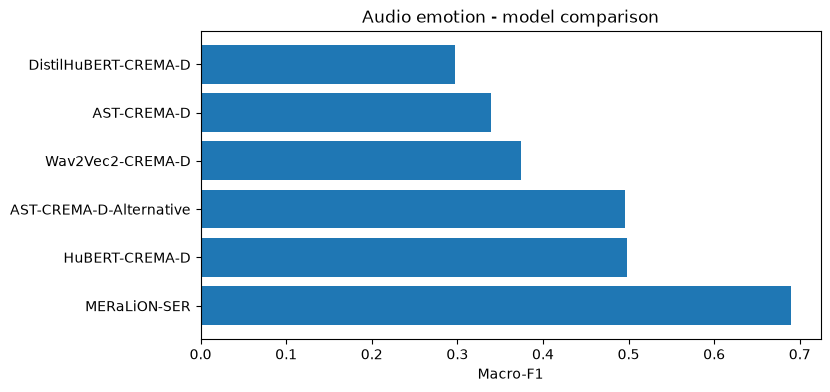

In [43]:
# bar graph for model comparision
plt.figure(figsize=(8, 4))
plt.barh(validation_results_df["Model"], validation_results_df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Audio emotion - model comparison")
plt.show()

In [44]:
# selected model name
selected_model_name = validation_results_df.loc[0, "Model"]
# selected model details
selected_model_details = models[selected_model_name]
# compute predictions
selected_validation_predictions = (validation_predictions[selected_model_name])

In [45]:
# print statements
print("Selected model:",selected_model_name)
print("Validation Macro-F1:", round(validation_results_df.loc[0, "Macro-F1"],4))
print("Inference time:",round(validation_results_df.loc[0, "Inference Time"], 2),"seconds")
print("Processing time:",round(validation_results_df.loc[0, "ms per Recording"], 2),"ms per recording")

Selected model: MERaLiON-SER
Validation Macro-F1: 0.6898
Inference time: 3352.12 seconds
Processing time: 4761.54 ms per recording


The test result assesses generalisation to new speakers rather than any additional tuning because the chosen model now proceeds to the reserved test split unchanged. Carrying forward the model's validation predictions alongside its identity also lets the later analysis compare validation and test behaviour directly and check for overfitting. The installed application, which can only execute one speech-emotion model per recording, is reflected in the commitment to a single model. The model is assessed using the held-out data in the following section.

## 9 Final Test Evaluation

Only the chosen model is evaluated once on the reserved testing split in this step. In order to evaluate the quality of the model's probability scores independently of the single hard prediction it produces per recording, its six-class accuracy and macro precision/recall/F1 are calculated, and one-vs-rest ROC and precision-recall curves are created for each emotion. Instead of depending solely on either, combining the threshold free AUC measures with the argmax-based macro-F1 provides a more comprehensive understanding of the model.

In [46]:
# actual test labels
actual_test_labels = (testing_data["emotion"].tolist())

In [47]:
# if selected model details is wav2vec2
if selected_model_details["loader"] == "wav2vec2":
    test_evaluation = run_wav2vec2_model(selected_model_details, testing_data)

# if selected model details is meralion
elif selected_model_details["loader"] == "meralion":
    test_evaluation = run_meralion_model(selected_model_details, testing_data)

# if selected model details is waveform pipeline
elif selected_model_details["loader"] == "waveform_pipeline":
    test_evaluation = run_waveform_pipeline_model(selected_model_details, testing_data)

else:
    # test evaluation
    test_evaluation = run_ast_model(selected_model_details, testing_data)

In [48]:
# read predictions
test_predictions = test_evaluation["predictions"]
# read probabilities
test_probabilities = test_evaluation["probabilities"]

In [49]:
if len(test_predictions) != len(actual_test_labels):
    # raise ValueError
    raise ValueError("The selected model returned an incorrect number of test predictions")

In [50]:
# calculate metrics
test_metrics = calculate_metrics(actual_test_labels,test_predictions)

In [51]:
# test results dataframe
test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    **test_metrics,
    "Loading Time": test_evaluation["loading_time"],
    "Inference Time": test_evaluation["inference_time"],
    "ms per Recording": (test_evaluation["inference_time"] / len(testing_data) * 1000)
}])

In [52]:
# test results dataframe
test_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms per Recording
0,MERaLiON-SER,0.673295,0.728322,0.674479,0.659367,6.311837,1624.973279,4616.401361


In [53]:
# print statements
print("Selected model:", selected_model_name)
print("Test Macro-F1:", round(test_metrics["Macro-F1"], 4))
print("Test Accuracy:", round(test_metrics["Accuracy"], 4))
print("Processing time:", round(test_results_df.loc[0, "ms per Recording"], 2), "ms per recording")

Selected model: MERaLiON-SER
Test Macro-F1: 0.6594
Test Accuracy: 0.6733
Processing time: 4616.4 ms per recording


**Analysis:** 

Near its validation macro-F1 of 0.6898, MERaLiON-SER achieves a macro-F1 of 0.6594 and accuracy of 0.6733 on the reserved testing split. Stable generalisation to the eight held-out speakers is shown by the narrow validation-to-test gap. Processing took approximately 4.62 seconds per recording in this run, including audio loading, preprocessing and inference.

In [54]:
# actual array
actual_array = np.array(actual_test_labels)
# separate ROC graph
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
# separate precision recall graph
fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
# roc auc scores in dictionary
roc_auc_scores = {}
# precision recall scores in dictionary
pr_auc_scores = {}
# prevent empty figures from appearing
plt.close(fig_roc)
plt.close(fig_pr)

In [55]:
for emotion in audio_emotions:
    # y true values
    y_true = (actual_array == emotion).astype(int)
    # y scores
    y_scores = np.array([probs.get(emotion, 0.0) for probs in test_probabilities])

    if y_true.sum() == 0:
        continue

    # roc scores
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    # auc scores
    roc_auc = auc(fpr, tpr)
    # roc auc scores
    roc_auc_scores[emotion] = roc_auc
    ax_roc.plot(fpr, tpr, label=f"{emotion.capitalize()} (AUC = {roc_auc:.3f})")

    # precision recall
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    # calculate the area under the precision recall curve
    pr_auc = auc(recall, precision)
    pr_auc_scores[emotion] = pr_auc
    ax_pr.plot(recall, precision, label=f"{emotion.capitalize()} (PR-AUC = {pr_auc:.3f})")

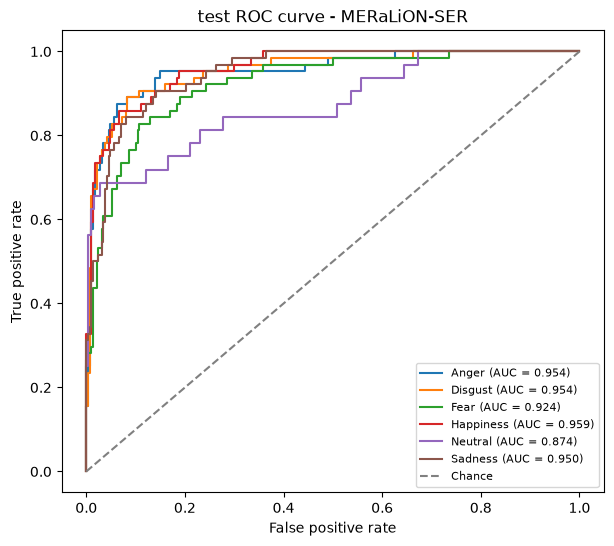

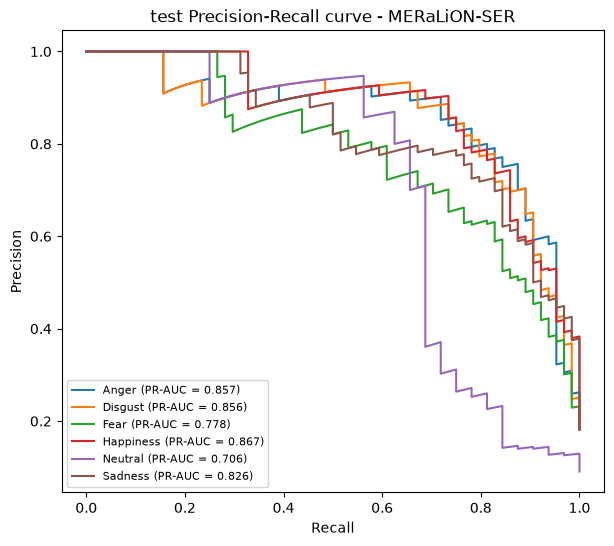

In [56]:
# graph for ROC and precision recall
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
# label the x-axis
ax_roc.set_xlabel("False positive rate")
# label the y-axis
ax_roc.set_ylabel("True positive rate")
# set the title
ax_roc.set_title(f"test ROC curve - {selected_model_name}")
# add the legend
ax_roc.legend(loc="lower right", fontsize=8)

# label the x-axis
ax_pr.set_xlabel("Recall")
# label the y-axis
ax_pr.set_ylabel("Precision")
# set the title
ax_pr.set_title(f"test Precision-Recall curve - {selected_model_name}")
# add the legend
ax_pr.legend(loc="lower left", fontsize=8)
# display the completed ROC graph
display(fig_roc)
# display the completed precision recall graph
display(fig_pr)

In [57]:
# print statements
print(f"Macro-average ROC-AUC: {np.mean(list(roc_auc_scores.values())):.3f}")
print(f"Macro-average PR-AUC:  {np.mean(list(pr_auc_scores.values())):.3f}")

Macro-average ROC-AUC: 0.936
Macro-average PR-AUC:  0.815


**Analysis:** 

The model's probability scores rank the emotions well beyond the single argmax choice, as demonstrated by the one-vs-rest curves the macro-averaged ROC-AUC is 0.936, and the macro-averaged PR-AUC is 0.815. The gap between the high ROC-AUC and the lower macro-F1 (0.6594) reflects that MERaLiON separates each emotion from the rest reliably, but the hard single-label prediction still confuses acoustically similar classes most visibly neutral against sadness.

Because the test speakers and recordings were held out of model selection entirely, these are the notebook's final, unbiased figures for the speech channel and the best available proxy for the model's behaviour on a new user voice. The gap between a high one-vs-rest ROC-AUC and a lower macro-F1, discussed below, is informative in its own right: it shows the model ranks each emotion against the rest well while still confusing acoustically similar classes when forced to commit to one label. These are the audio results cited in the study. These misunderstandings become tangible in the confusion matrix that follows.

## 10 Confusion Matrix

For the chosen model on the test split, this section creates a single six-class confusion matrix and stores it in the output folder. Unlike the binary per-emotion matrices in the text notebook, one multiclass matrix is appropriate here because the audio task is a genuine six-way single-label classification, so the full matrix shows every cross-emotion confusion at once.

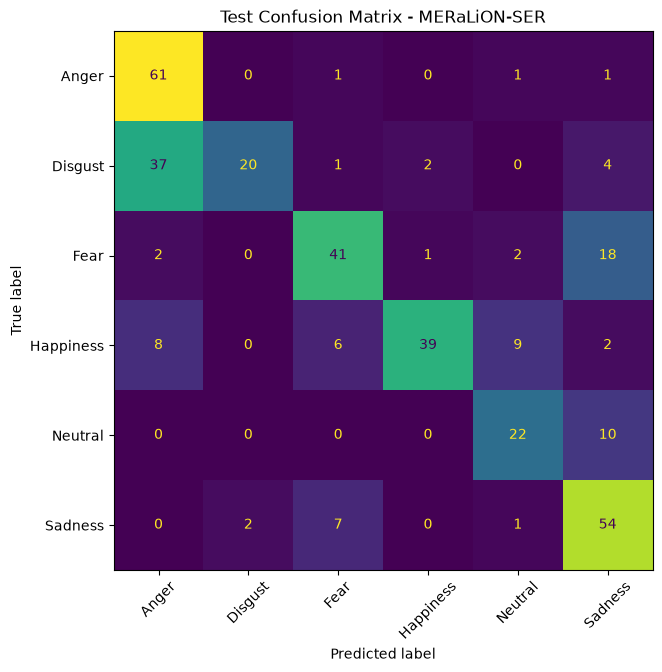

In [58]:
# create the confusion matrix
figure, axis = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(actual_test_labels,test_predictions,labels=audio_emotions,display_labels=[emotion.capitalize() for emotion in audio_emotions], xticks_rotation=45,ax=axis, colorbar=False)
axis.set_title(f"Test Confusion Matrix - {selected_model_name}")
plt.savefig(output_folder / "selected_audio_model_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

**Analysis:** 

The confusion matrix confirms where the residual errors fall. Anger and happiness are recognised most reliably, while neutral is the hardest class several neutral recordings are predicted as sadness, reflecting their similar low arousal. This is consistent with the recognised difficulty distinguishing between calm, neutral, and sad speech and reflects the decreased per-class recall behind the 0.6594 macro-F1.

The aggregate macro-F1 becomes interpretable in the matrix, which reveals precisely which emotions are confused for which, most notably the tendency to misinterpret similar sounding low-arousal classes like neutral and sadness. This is diagnostic information that cannot be expressed by a single score and is directly related to a wellbeing tool, where it would be costly to consistently confuse calm with distress. Saving the figure keeps the report's qualitative claims backed by a reproducible artefact. All results are retained in the final section.

## 11 Saving Results

Lastly, the output folder's CSV file contains the model comparison, the chosen model's test results, and its per-recording predictions. The errors can be reexamined later, by emotion, by actor, or by scenario, without re-running any model, if the per-recording predictions are saved along with the summary tables.

In [59]:
# save to CSV
validation_results_df.to_csv(output_folder / "audio_model_comparison.csv",index=False)
test_results_df.to_csv(output_folder / "selected_audio_model_test_results.csv", index=False)

In [60]:
# test predictions dataframe
test_predictions_df = pd.DataFrame({
    # set the "actor" field
    "actor": testing_data["actor"].astype(int).tolist(),
    # set the "Actual Emotion" field
    "Actual Emotion": actual_test_labels,
    # set the "Predicted Emotion" field
    "Predicted Emotion": test_predictions
})

In [61]:
# test predictions dataframe
test_predictions_df.head()

,actor,Actual Emotion,Predicted Emotion
0,17,neutral,sadness
1,17,neutral,neutral
2,17,neutral,neutral
3,17,neutral,neutral
4,17,happiness,happiness


In [62]:
# save to CSV
test_predictions_df.to_csv(output_folder / "selected_audio_model_test_predictions.csv", index=False)
print("Results saved in:", output_folder)

Results saved in: outputs\audio


The audio experiment is finished and repeatable after the results are written, and each figure cited in the report can be linked to a stored file rather than a temporary output. In subsequent studies, a more thorough error analysis or a fairness check between speakers might be possible if the raw per-recording forecasts were retained. The model selected for the voice channel of the application is named in the conclusion that follows, which summarises the results.

## 12 Conclusion

The actor-independent RAVDESS validation split was used to compare six pretrained speech-emotion models. Because MERaLiON-SER outperformed the five CREMA-D models with the highest validation macro-F1 of 0.6898, it was chosen as the final audio model.

Along with macro-averaged ROC-AUC of 0.936 and PR-AUC of 0.815, MERaLiON-SER achieved macro-F1 of 0.6594 and accuracy of 0.6733 on the reserved testing split, which is comparable to its validation performance. Anger and happiness were recognised most reliably, while neutral was the weakest class and was most often confused with sadness. Processing took approximately 4.62 seconds per recording in this run, including audio loading, preprocessing and inference.

MERaLiON-SER will thus be the speech emotional model used in the final multimodal wellbeing-monitoring application. The evaluation was limited to anger, disgust, fear, happiness, neutral and sadness because these were the emotion classes shared by every candidate model. Calm and surprise recordings were excluded from this evaluation.

## 13 References

[1] S. R. Livingstone and F. A. Russo, "The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS): a dynamic, multimodal set of facial and vocal expressions in North American English," 2018. [Online]. Available: https://doi.org/10.1371/journal.pone.0196391. [Accessed: 5 June 2026].

[2] A. Baevski, H. Zhou, A. Mohamed, and M. Auli, "wav2vec 2.0: a framework for self-supervised learning of speech representations," 2020. [Online]. Available: https://arxiv.org/abs/2006.11477. [Accessed: 31 May 2026].

[3] Y. Gong, Y.-A. Chung, and J. Glass, "AST: Audio Spectrogram Transformer," 2021. [Online]. Available: https://arxiv.org/abs/2104.01778. [Accessed: 23 June 2026].